# 스마트 창고 출고 지연 예측 — Model v3

v2 대비 변경 사항:
- 시계열 피처 적용 대상 확장 (10개 → 20개)
- `layout_id` OOF 타겟 인코딩 추가 (leakage 방지)
- 시나리오 진행률 피처 추가
- 추가 교차 피처 추가
- Optuna 앙상블 가중치 최적화 (모델 재튜닝 없음)

## 0. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

SEED    = 42
N_FOLD  = 5
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 1. v2 최적 파라미터 입력

> **v2 노트북 출력의 `Best params` 값을 아래에 붙여넣으세요.**  
> 없으면 기본값으로 진행합니다 (피처 셋이 달라져 재튜닝 없이도 합리적인 성능 기대 가능).

In [2]:

lgb_best = {'n_estimators': 700, 'learning_rate': 0.011479253721973068, 'max_depth': 7, 'num_leaves': 157, 'subsample': 0.9417089137635153, 'colsample_bytree': 0.7182509076515207, 'reg_alpha': 0.002313051327322259, 'reg_lambda': 0.007098159082336851, 'min_child_samples': 70, 'random_state': 42, 'verbose': -1, 'n_jobs': -1}
xgb_best = {'n_estimators': 1700, 'learning_rate': 0.010069367505586393, 'max_depth': 8, 'subsample': 0.7701921669162993, 'colsample_bytree': 0.6281558321428306, 'reg_alpha': 0.00681854496911729, 'reg_lambda': 5.936330336429031, 'min_child_weight': 17, 'gamma': 1.217006530058639, 'random_state': 42, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 100}
cat_best = {'iterations': 2000, 'learning_rate': 0.011496997241230818, 'depth': 10, 'l2_leaf_reg': 5.1253106234016546, 'bagging_temperature': 0.04857511330881678, 'random_strength': 0.002172876360345995, 'border_count': 56, 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 100, 'task_type': 'CPU'}

print('파라미터 설정 완료')

파라미터 설정 완료


## 2. 데이터 로드 및 기본 전처리

In [3]:
train  = pd.read_csv('./open/train.csv')
test   = pd.read_csv('./open/test.csv')
layout = pd.read_csv('./open/layout_info.csv')

# layout_info merge
train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

# layout_type 레이블 인코딩
le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'].astype(str))
test['layout_type']  = le.transform(test['layout_type'].astype(str))

# 시나리오 내 정렬
train = train.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)
test  = test.sort_values(['scenario_id',  'shift_hour']).reset_index(drop=True)

print(f'train: {train.shape} / test: {test.shape}')

train: (250000, 108) / test: (50000, 107)


## 3. 시계열 피처 생성 (확장: 10 → 20개)

In [4]:
# 어블레이션: ts_features를 v2와 동일한 10개로 되돌림
# (20개 확장 시 v2 Optuna params 기준 underfitting 발생 확인)
ts_features = [
    'order_inflow_15m', 'robot_utilization', 'congestion_score',
    'fault_count_15m',  'loading_dock_util', 'battery_mean',
    'blocked_path_15m', 'task_reassign_15m', 'low_battery_ratio',
    'avg_trip_distance',
]

def make_ts_features(df, cols, group_col='scenario_id'):
    df = df.copy()
    grp = df.groupby(group_col)
    for col in cols:
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = grp[col].shift(lag)
        for win in [3, 5]:
            df[f'{col}_roll_mean{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=1).mean())
            df[f'{col}_roll_std{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=2).std())
        df[f'{col}_cumsum'] = grp[col].transform(lambda x: x.shift(1).cumsum())
    return df

print('시계열 피처 생성 중...')
train = make_ts_features(train, ts_features)
test  = make_ts_features(test,  ts_features)
print(f'시계열 피처 생성 완료 | train: {train.shape}')

시계열 피처 생성 중...
시계열 피처 생성 완료 | train: (250000, 188)


## 4. layout_id OOF 타겟 인코딩

- train: Group K-Fold OOF 방식 → 데이터 누수 없음
- test: 전체 train 기준 통계값 사용

In [5]:
# 어블레이션: 타겟 인코딩 비활성화
# (ts_features 10개 기준에서 타겟 인코딩 영향만 분리하기 위해 스킵)
print('타겟 인코딩 스킵 (어블레이션)')

타겟 인코딩 스킵 (어블레이션)


## 5. 추가 피처 엔지니어링

In [6]:
def make_extra_features(df):
    df = df.copy()

    # ── v2와 동일 ──────────────────────────────────────────────
    df['time_step']          = df.groupby('scenario_id').cumcount()
    df['robot_active_ratio'] = df['robot_active'] / (
        df['robot_active'] + df['robot_idle'] + df['robot_charging'] + 1e-6)
    df['battery_congestion'] = df['low_battery_ratio'] * df['congestion_score']
    df['urgent_volume']      = df['urgent_order_ratio'] * df['order_inflow_15m']
    df['fault_impact']       = df['fault_count_15m'] * df['avg_recovery_time']
    df['dock_stress']        = df['outbound_truck_wait_min'] * df['loading_dock_util']

    # ── v3 신규 추가 ──────────────────────────────────────────
    # 시나리오 진행률 (0.0 ~ 1.0)
    df['time_step_ratio']    = df['time_step'] / 23.0

    # 초반/후반 단계 플래그
    df['is_early_step']      = (df['time_step'] <= 3).astype(np.int8)
    df['is_late_step']       = (df['time_step'] >= 20).astype(np.int8)

    # 로봇 효율 종합 지표
    df['robot_efficiency']   = df['agv_task_success_rate'] * df['robot_utilization']

    # 충전 병목 × 혼잡도
    df['charge_congestion']  = df['charge_queue_length'] * df['congestion_score']

    # 주문 처리 압박 지수 (긴급 + 대량 주문 동시 유입)
    df['order_pressure']     = (
        df['urgent_order_ratio'] + df['bulk_order_ratio']) * df['order_inflow_15m']

    # OTD 저하 × 백로그 (운영 악화 복합 지표)
    df['ops_stress']         = (1 - df['kpi_otd_pct']) * df['backorder_ratio']

    # 경로 품질 × AGV 성공률
    df['routing_quality']    = df['path_optimization_score'] * df['agv_task_success_rate']

    return df

train = make_extra_features(train)
test  = make_extra_features(test)
print(f'추가 피처 후 train: {train.shape}')

추가 피처 후 train: (250000, 202)


## 6. 피처 / 타겟 설정

In [7]:
feat_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
X         = train[feat_cols]
y         = train[TARGET]
X_test    = test[feat_cols]
groups    = train['scenario_id']

print(f'피처 수 : {len(feat_cols)}')
print(f'v2 대비 : +{len(feat_cols) - 190}개  (ts 10개 유지 + 신규 교차 피처만 추가)')

피처 수 : 198
v2 대비 : +8개  (ts 10개 유지 + 신규 교차 피처만 추가)


## 7. Group K-Fold 학습

In [8]:
gkf5 = GroupKFold(n_splits=N_FOLD)

def run_cv(model_fn, model_name, fit_kwargs_fn=None):
    oof   = np.zeros(len(X))
    preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(gkf5.split(X, y, groups)):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_fn()
        if fit_kwargs_fn:
            model.fit(X_tr, y_tr, **fit_kwargs_fn(X_val, y_val))
        else:
            model.fit(X_tr, y_tr)

        oof[val_idx] = model.predict(X_val)
        preds       += model.predict(X_test) / N_FOLD

        score = rmse(y_val, oof[val_idx])
        fold_scores.append(score)
        print(f'  [{model_name}] Fold {fold+1}  RMSE: {score:.4f}')

    total = rmse(y, oof)
    print(f'  [{model_name}] OOF RMSE: {total:.4f}\n')
    return oof, preds, total

In [9]:
print('=== LightGBM ===')
lgb_oof, lgb_pred, lgb_score = run_cv(
    lambda: LGBMRegressor(**lgb_best),
    'LGB',
    lambda xv, yv: {
        'eval_set': [(xv, yv)],
        'callbacks': [lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)]
    }
)

=== LightGBM ===
[500]	valid_0's l2: 480.443
  [LGB] Fold 1  RMSE: 21.9072
[500]	valid_0's l2: 459.72
  [LGB] Fold 2  RMSE: 21.4146
[500]	valid_0's l2: 392.106
  [LGB] Fold 3  RMSE: 19.8001
[500]	valid_0's l2: 502.335
  [LGB] Fold 4  RMSE: 22.3864
  [LGB] Fold 5  RMSE: 21.0904
  [LGB] OOF RMSE: 21.3378



In [10]:
print('=== XGBoost ===')
xgb_oof, xgb_pred, xgb_score = run_cv(
    lambda: XGBRegressor(**xgb_best),
    'XGB',
    lambda xv, yv: {'eval_set': [(xv, yv)], 'verbose': False}
)

=== XGBoost ===
  [XGB] Fold 1  RMSE: 21.9056
  [XGB] Fold 2  RMSE: 21.3751
  [XGB] Fold 3  RMSE: 19.7385
  [XGB] Fold 4  RMSE: 22.3971
  [XGB] Fold 5  RMSE: 21.0565
  [XGB] OOF RMSE: 21.3137



In [11]:
print('=== CatBoost ===')
cat_oof, cat_pred, cat_score = run_cv(
    lambda: CatBoostRegressor(**cat_best),
    'CAT',
    lambda xv, yv: {'eval_set': (xv, yv)}
)

=== CatBoost ===
  [CAT] Fold 1  RMSE: 21.9914
  [CAT] Fold 2  RMSE: 21.4541
  [CAT] Fold 3  RMSE: 19.8718
  [CAT] Fold 4  RMSE: 22.3921
  [CAT] Fold 5  RMSE: 21.1395
  [CAT] OOF RMSE: 21.3873



## 8. Optuna 앙상블 가중치 최적화

모델 재학습 없이 OOF 예측값만으로 최적 가중치 탐색 (수초 내 완료)

In [12]:
def ens_objective(trial):
    w_lgb = trial.suggest_float('w_lgb', 0.0, 1.0)
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
    w_cat = trial.suggest_float('w_cat', 0.0, 1.0)
    total = w_lgb + w_xgb + w_cat
    if total < 1e-6:
        return 1e9
    w_lgb /= total
    w_xgb /= total
    w_cat /= total
    ens = w_lgb * lgb_oof + w_xgb * xgb_oof + w_cat * cat_oof
    return rmse(y, ens)

print('Optuna 앙상블 가중치 탐색 중 (500 trials)...')
ens_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
ens_study.optimize(ens_objective, n_trials=500, show_progress_bar=True)

bw = ens_study.best_params
total_w = bw['w_lgb'] + bw['w_xgb'] + bw['w_cat']
w_lgb_opt = bw['w_lgb'] / total_w
w_xgb_opt = bw['w_xgb'] / total_w
w_cat_opt = bw['w_cat'] / total_w

print(f'\n최적 가중치  LGB: {w_lgb_opt:.4f} | XGB: {w_xgb_opt:.4f} | CAT: {w_cat_opt:.4f}')
print(f'Optuna 앙상블 OOF RMSE: {ens_study.best_value:.4f}')

Optuna 앙상블 가중치 탐색 중 (500 trials)...


  0%|          | 0/500 [00:00<?, ?it/s]


최적 가중치  LGB: 0.2026 | XGB: 0.4702 | CAT: 0.3272
Optuna 앙상블 OOF RMSE: 21.2785


## 9. 앙상블 비교 및 최종 선택

In [13]:
# 세 가지 앙상블 비교
inv_scores  = 1 / np.array([lgb_score, xgb_score, cat_score])
inv_weights = inv_scores / inv_scores.sum()

rmse_oof_ens   = inv_weights[0]*lgb_oof + inv_weights[1]*xgb_oof + inv_weights[2]*cat_oof
rmse_pred_ens  = inv_weights[0]*lgb_pred + inv_weights[1]*xgb_pred + inv_weights[2]*cat_pred
score_rmse_ens = rmse(y, rmse_oof_ens)

optuna_oof   = w_lgb_opt*lgb_oof  + w_xgb_opt*xgb_oof  + w_cat_opt*cat_oof
optuna_pred  = w_lgb_opt*lgb_pred + w_xgb_opt*xgb_pred + w_cat_opt*cat_pred
score_optuna = rmse(y, optuna_oof)

simple_oof   = (lgb_oof  + xgb_oof  + cat_oof)  / 3
simple_pred  = (lgb_pred + xgb_pred + cat_pred) / 3
score_simple = rmse(y, simple_oof)

print('=' * 55)
print('앙상블 방식별 OOF RMSE 비교')
print('=' * 55)
print(f'  단순 평균          : {score_simple:.4f}')
print(f'  RMSE 역수 가중     : {score_rmse_ens:.4f}')
print(f'  Optuna 최적 가중   : {score_optuna:.4f}  ← 최적')
print()
print(f'  v2 앙상블 대비 개선 : {21.2717 - min(score_simple, score_rmse_ens, score_optuna):+.4f}')

# 최적 앙상블 선택
candidates = [
    (score_simple,   simple_pred,  '단순평균'),
    (score_rmse_ens, rmse_pred_ens, 'RMSE역수가중'),
    (score_optuna,   optuna_pred,  'Optuna최적'),
]
best_score, best_pred, best_label = min(candidates, key=lambda x: x[0])
print(f'\n선택된 앙상블: {best_label}  (RMSE: {best_score:.4f})')

앙상블 방식별 OOF RMSE 비교
  단순 평균          : 21.2799
  RMSE 역수 가중     : 21.2799
  Optuna 최적 가중   : 21.2785  ← 최적

  v2 앙상블 대비 개선 : -0.0068

선택된 앙상블: Optuna최적  (RMSE: 21.2785)


## 10. 버전별 성능 비교 시각화

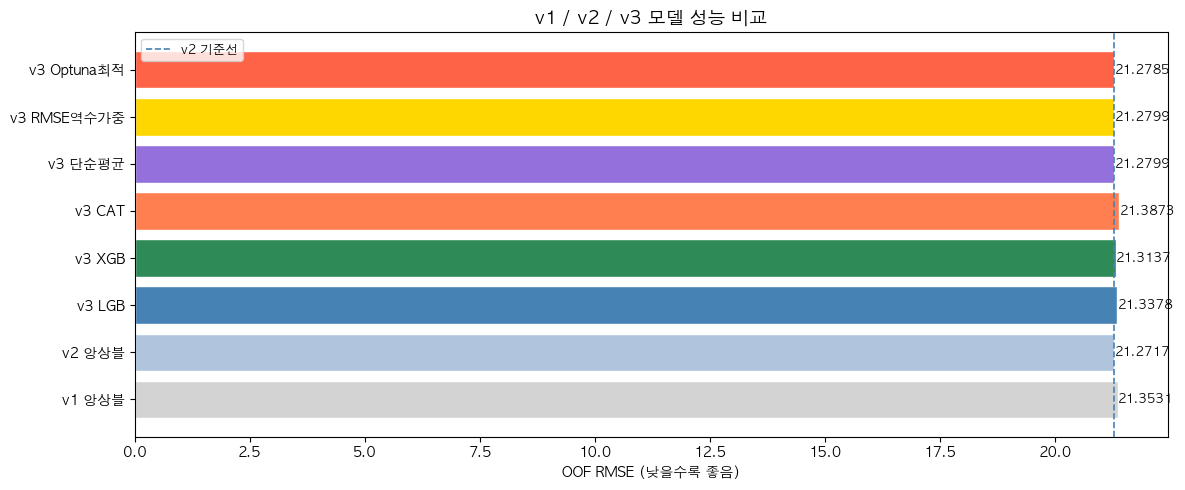

In [14]:
model_names  = [
    'v1 앙상블', 'v2 앙상블',
    'v3 LGB', 'v3 XGB', 'v3 CAT',
    'v3 단순평균', 'v3 RMSE역수가중', 'v3 Optuna최적'
]
model_scores = [
    21.3531, 21.2717,
    lgb_score, xgb_score, cat_score,
    score_simple, score_rmse_ens, score_optuna
]
colors = ['lightgray', 'lightsteelblue',
          'steelblue', 'seagreen', 'coral',
          'mediumpurple', 'gold', 'tomato']

plt.figure(figsize=(12, 5))
bars = plt.barh(model_names, model_scores, color=colors, edgecolor='white')
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=9)
plt.axvline(21.2717, color='steelblue', linestyle='--', linewidth=1.2, label='v2 기준선')
plt.xlabel('OOF RMSE (낮을수록 좋음)')
plt.title('v1 / v2 / v3 모델 성능 비교', fontsize=13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11. 제출 파일 생성

In [15]:
submission = pd.read_csv('./open/sample_submission.csv')
submission[TARGET] = best_pred
submission.to_csv('./submission_v3.csv', index=False)

print(f'submission_v3.csv 저장 완료  ({best_label}, RMSE: {best_score:.4f})')
print(submission[TARGET].describe().round(4))

submission_v3.csv 저장 완료  (Optuna최적, RMSE: 21.2785)
count    50000.0000
mean        23.6404
std         17.3385
min          0.8710
25%          6.7769
50%         20.2251
75%         37.9313
max        115.5415
Name: avg_delay_minutes_next_30m, dtype: float64
